In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Result Experiment 1

In [3]:
# load results of Experiment 1
results_experiment_1 = pd.read_csv("../experiment_1_results.csv")
results_experiment_1

,class,image,prompt,num_detections,max_confidence
0,dog,000000030494.jpg,dog,1,0.961972
1,dog,000000030494.jpg,animal,1,0.924298
2,dog,000000030494.jpg,mammal,1,0.776220
3,dog,000000030494.jpg,living thing,1,0.530475
4,dog,000000049269.jpg,dog,1,0.883610
...,...,...,...,...,...
230,chair,000000269932.jpg,furniture,1,0.769212
231,chair,000000269932.jpg,object,1,0.522677
232,chair,000000353970.jpg,chair,2,0.425412
233,chair,000000353970.jpg,furniture,1,0.493677


In [5]:
classes = results_experiment_1["class"].unique()
classes

array(['dog', 'cat', 'bird', 'car', 'bicycle', 'chair'], dtype=object)

In [7]:
avg_conf = (
    results_experiment_1.groupby(["class", "prompt"])["max_confidence"]
      .mean()
      .reset_index()
)
avg_conf

,class,prompt,max_confidence
0,bicycle,bicycle,0.630476
1,bicycle,object,0.450314
2,bicycle,vehicle,0.000000
3,bird,animal,0.811945
4,bird,bird,0.824740
5,bird,living thing,0.488613
6,car,car,0.680521
7,car,object,0.425294
8,car,vehicle,0.173836
9,cat,animal,0.775887


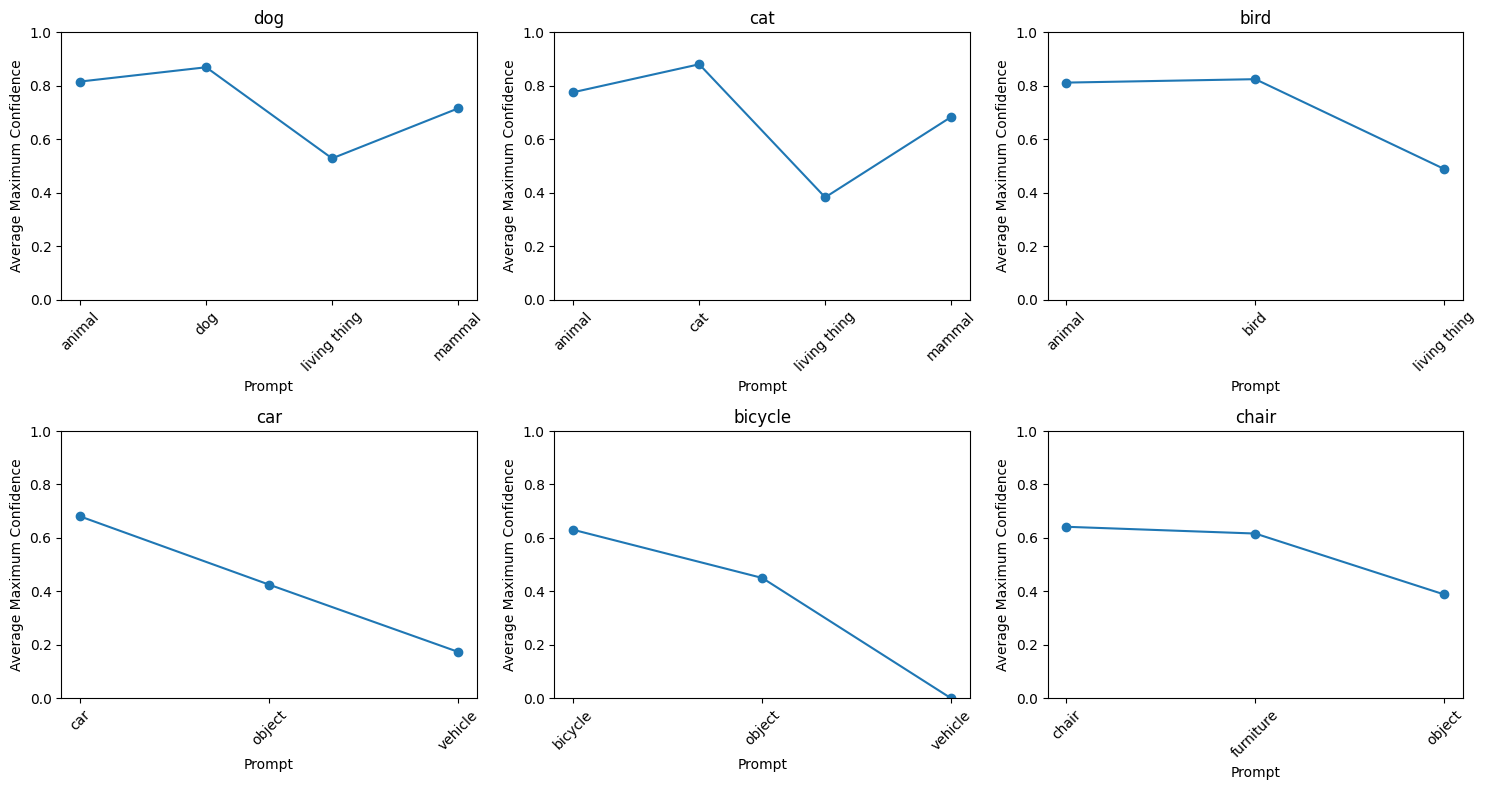

In [8]:
n_classes = len(classes)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fix, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    squeeze=False
)
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    class_data = avg_conf[avg_conf["class"] == cls]
    ax.plot(
        class_data["prompt"],
        class_data["max_confidence"],
        marker='o'
    )
    ax.set_title(cls)
    ax.set_xlabel("Prompt")
    ax.set_ylabel("Average Maximum Confidence")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Result Experiment 2

In [9]:
# load results of Experiment 1
results_experiment_2 = pd.read_csv("../experiment_2_results.csv")
results_experiment_2

,image,prompt,num_detections,avg_confidence
0,000000000632.jpg,object,0,0.000000
1,000000000632.jpg,thing,0,0.000000
2,000000000632.jpg,animal,0,0.000000
3,000000000632.jpg,vehicle,0,0.000000
4,000000005001.jpg,object,1,0.352621
...,...,...,...,...
331,000000343976.jpg,vehicle,1,0.350819
332,000000344909.jpg,object,1,0.684149
333,000000344909.jpg,thing,1,0.668072
334,000000344909.jpg,animal,1,0.650062


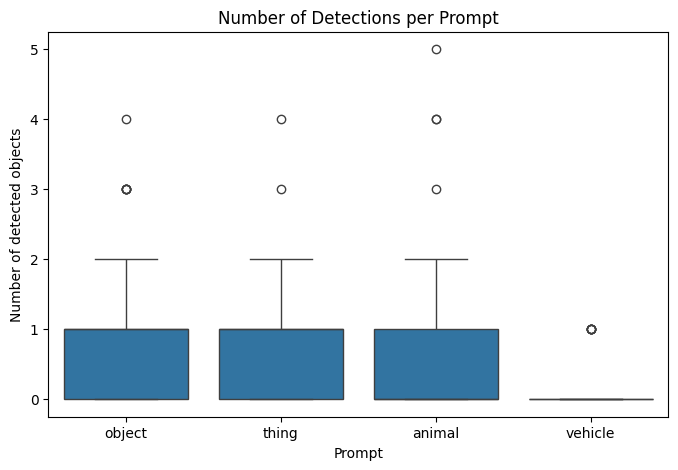

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=results_experiment_2,
    x="prompt",
    y="num_detections"
)

plt.title("Number of Detections per Prompt")
plt.xlabel("Prompt")
plt.ylabel("Number of detected objects")
plt.show()

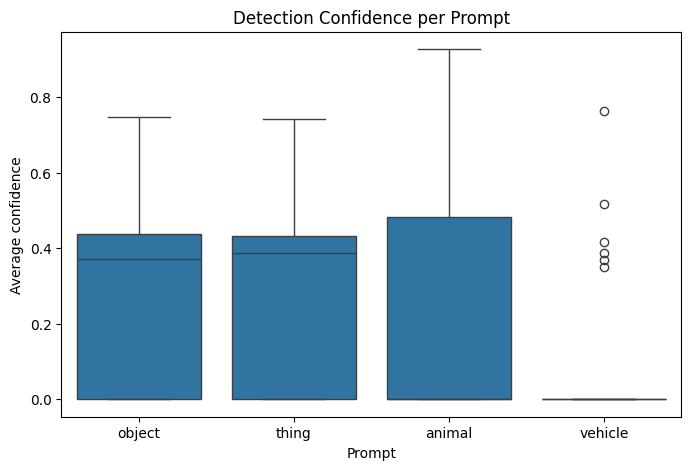

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=results_experiment_2,
    x="prompt",
    y="avg_confidence"
)

plt.title("Detection Confidence per Prompt")
plt.xlabel("Prompt")
plt.ylabel("Average confidence")

plt.show()